### **Autor:** David Roca Tauste

---
---
# **📌ACTIVIDAD 2: UN CASO DE REGRESIÓN MÁS REAL**
---
---

## COMPARATIVA DE VARIOS REGRESORES

In [29]:
import numpy as np
import pandas as pd

dataset = pd.read_csv('centro-comercial.csv')
semilla = 546

## PRIMERA ETAPA: EDA

Muestra unas filas del dataset y cuantas características y ejemplos tiene.

In [30]:
dataset.head()

,centro,fecha,ventas_semanales,festivo,temperatura,precio_gasolina,IPC,desempleo
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [31]:
print(f"Tiene {dataset.columns.size} características y {dataset.size} ejemplos.")

Tiene 8 características y 51480 ejemplos.


Cambiar la característica fecha por 3 características nuevas: día de la semana, mes y año. Puedes convertir las fechas en tipo Date con la función de pandas to_datetime(fecha, formato) donde tendrás que indicar el formato porque utiliza por defecto el inglés. El formato es un texto con comodines donde %d es el día, %m es el mes y %Y es el año con 4 dígitos. Cuando la tengas convertida a tipo Date puedes extraerle información con expresiones como pd.fecha.dt.year que te devuelve el año.

In [32]:
dataset['fecha'] = pd.to_datetime(dataset['fecha'], format='%d-%m-%Y')

dataset['dia'] = dataset['fecha'].dt.day
dataset['mes'] = dataset['fecha'].dt.month
dataset['año'] = dataset['fecha'].dt.year

In [33]:
dataset = dataset.drop("fecha", axis=1)
dataset.head()

,centro,ventas_semanales,festivo,temperatura,precio_gasolina,IPC,desempleo,dia,mes,año
0,1,1643690.90,0,42.31,2.572,211.096358,8.106,5,2,2010
1,1,1641957.44,1,38.51,2.548,211.242170,8.106,12,2,2010
2,1,1611968.17,0,39.93,2.514,211.289143,8.106,19,2,2010
3,1,1409727.59,0,46.63,2.561,211.319643,8.106,26,2,2010
4,1,1554806.68,0,46.50,2.625,211.350143,8.106,5,3,2010


Ahora cuenta y muestra la cantidad de diferentes valores que tiene cada característica con df.nunique() para detectar posibles problemas (que haya 13 meses por ejemplo) o detectar las que quizás sean booleanas (tendrán 2 valores) y en definitiva comprender mejor los datos.

In [34]:
dataset.nunique()

centro                45
ventas_semanales    6435
festivo                2
temperatura         3528
precio_gasolina      892
IPC                 2145
desempleo            349
dia                   31
mes                   12
año                    3
dtype: int64

Definimos una variable target que será "ventas_semanales" y otra de tipo lista llamada predictoras que contenga el resto de características menos el target.

In [35]:
variable_objetivo = "ventas_semanales"

target = dataset[variable_objetivo]
predictoras = dataset.drop(variable_objetivo, axis=1)

Intentamos detectar qué características pueden ser pueden ser categóricas y cuales pueden ser numéricas usando el criterio de la cantidad de valores diferentes que tengan. Si una característica tiene menos del 0.5% de sus valores distintos es sospechosa de ser categórica aunque sus valores sean numéricos. Completa el código que crea la lista nf con los nombres de las características numéricas y la lista cf con las categóricas y las imprima:

In [36]:
nu = predictoras.nunique().sort_values()
nf = []; cf = []; # numéricas (nf) y categóricas (cf)

In [37]:
umbral = len(predictoras) * 0.005

for col in nu.index:
    if nu[col] <= umbral:
        cf.append(col)
    else:
        nf.append(col)

print(f"El Dataset tiene {len(nf)} numéricas y {len(cf)} categóricas.")
print("Numéricas:", nf)
print("Categóricas:", cf)

El Dataset tiene 5 numéricas y 4 categóricas.
Numéricas: ['centro', 'desempleo', 'precio_gasolina', 'IPC', 'temperatura']
Categóricas: ['festivo', 'año', 'mes', 'dia']


Dibujar un histograma del target con seaborn por ejemplo usando histplot().

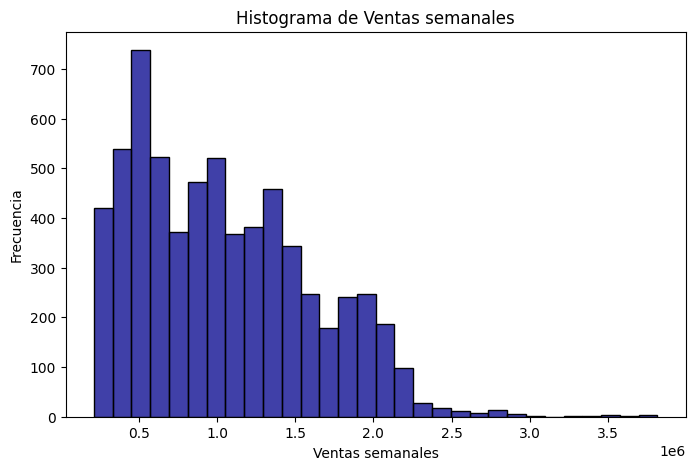

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(target, bins=30, color='darkblue')
plt.title('Histograma de Ventas semanales')
plt.xlabel('Ventas semanales')
plt.ylabel('Frecuencia')
plt.show()

Completa este código que dibuja las distribuciones de las características numéricas para que aparezca debajo del histograma de cada característica su boxplot y nos permitan visualizar la presencia de outliers, tal y como se ve en la figura.

                                           Distribuciones de Características Numéricas                                            


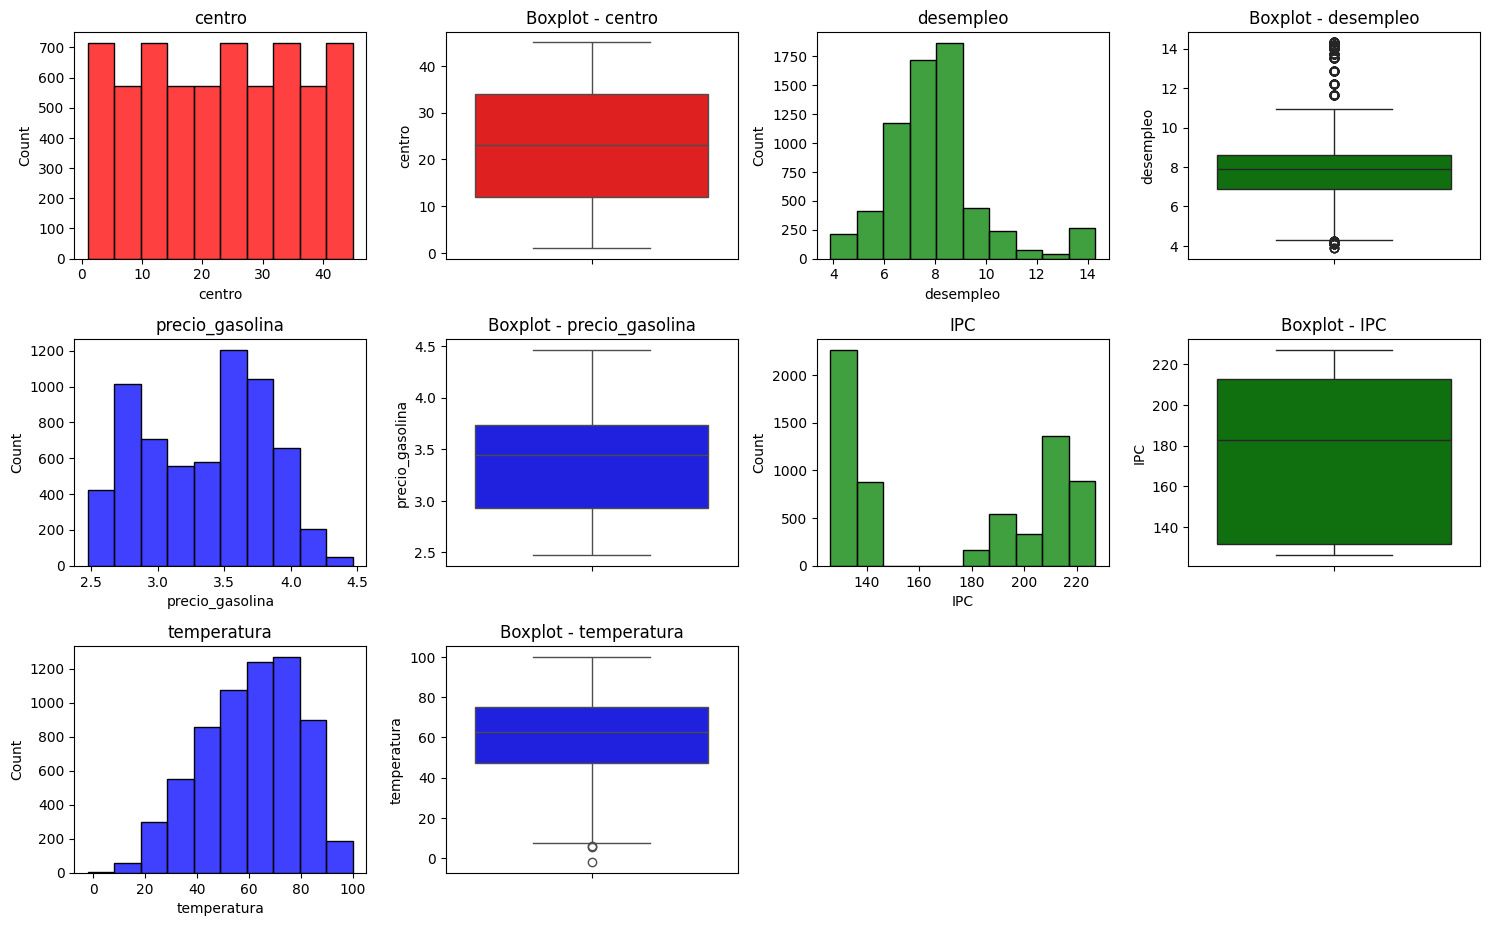

In [39]:
import math

print('Distribuciones de Características Numéricas'.center(130))
n = 4
clr = ['r', 'g', 'b', 'g', 'b', 'g', 'b', 'r']

plt.figure(figsize=[15, 6 * math.ceil(len(nf) / n)])

for i in range(len(nf)):
    # Histograma
    plt.subplot(math.ceil(len(nf) / n) * 2, n, i * 2 + 1)
    sns.histplot(dataset[nf[i]], bins=10, color=clr[i % len(clr)], edgecolor='black')
    plt.title(nf[i])

for i in range(len(nf)):
    # Boxplot
    plt.subplot(math.ceil(len(nf) / n) * 2, n, i * 2 + 2)
    sns.boxplot(y=dataset[nf[i]], color=clr[i % len(clr)])
    plt.title(f'Boxplot - {nf[i]}')

plt.tight_layout()
plt.show()


## SEGUNDA ETAPA: SELECCIÓN DE CARACTERÍSTICAS

Elimina características del dataframe que no son útiles, y también debes borrarlas de las listas de predictoras y de cualquier otra lista donde aparezcan.

In [40]:
predictoras = predictoras.drop("IPC", axis=1)
dataset = dataset.drop("IPC", axis=1)

In [41]:
print("Lista predictoras:")
print(predictoras.columns)

print("\nLista columnas dataset:")
print(dataset.columns)

Lista predictoras:
Index(['centro', 'festivo', 'temperatura', 'precio_gasolina', 'desempleo',
       'dia', 'mes', 'año'],
      dtype='object')

Lista columnas dataset:
Index(['centro', 'ventas_semanales', 'festivo', 'temperatura',
       'precio_gasolina', 'desempleo', 'dia', 'mes', 'año'],
      dtype='object')


He considerado eliminar la columna IPC porque hay una clara separación entre los datos, cómo podemos ver tanto en el histograma como en el boxplot.

Realiza operaciones de limpieza que consideres necesarias. Crea un objeto llamado preprocesador de tipo ColumnTransformer que pueda utilizarse para aplicar transformaciones cuando se necesiten:
- Tratamiento de valores ausentes.
- Eliminación de filas repetidas.
- Tratamiento de outliers.
- Codificación de variables categóricas.
- Escalado o estandarización.

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin

# 1. Personalizado: Eliminación de duplicados y outliers
class CustomCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, outlier_method='iqr'):
        self.outlier_method = outlier_method

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.drop_duplicates()

        if self.outlier_method == 'iqr':
            for col in X.select_dtypes(include=[np.number]).columns:
                Q1 = X[col].quantile(0.25)
                Q3 = X[col].quantile(0.75)
                IQR = Q3 - Q1
                lower = Q1 - 1.5 * IQR
                upper = Q3 + 1.5 * IQR
                X = X[(X[col] >= lower) & (X[col] <= upper)]
        return X

# 2. Identifica columnas numéricas y categóricas
def get_columns(df):
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    return num_cols, cat_cols

# 3. Pipelines para datos numéricos y categóricos
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# 4. Preprocesador con ColumnTransformer
preprocesador = Pipeline(steps=[
    ('transform', ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, lambda df: df.select_dtypes(include=['int64', 'float64']).columns),
            ('cat', categorical_transformer, lambda df: df.select_dtypes(include=['object', 'category']).columns)
        ],
        remainder='passthrough'
    ))
])


In [43]:
predictoras_preprocesadas = preprocesador.fit_transform(predictoras)
dataset_preprocesado = preprocesador.fit_transform(dataset)

Estudia la colinealidad entre las predictoras y el target y entre cada pareja de predictoras numéricas calculando la matriz de correlaciones de las características numéricas y visualizando un mapa de calor de color azul y blanco. Elimina predictoras que presenten una correlación superior al 60%.

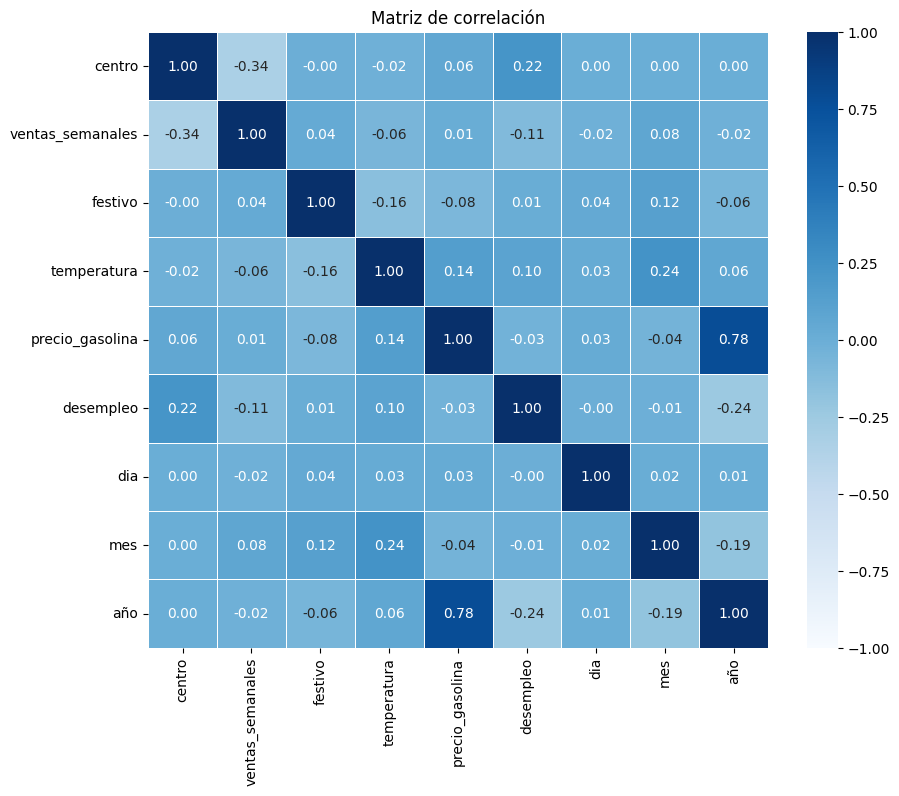

In [44]:
numericas_df = dataset.select_dtypes(include=['number'])

# Matriz de correlaciones
matriz_corr = numericas_df.corr()
    
# Mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, cmap='Blues', annot=True, fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Matriz de correlación")
plt.show()

In [45]:
print("Correlación con el target:")
print(matriz_corr[variable_objetivo].sort_values(ascending=False))

Correlación con el target:
ventas_semanales    1.000000
mes                 0.076143
festivo             0.036891
precio_gasolina     0.009464
dia                -0.017409
año                -0.018378
temperatura        -0.063810
desempleo          -0.106176
centro             -0.335332
Name: ventas_semanales, dtype: float64


He decidio eliminar la columna 'año' debido a que tiene una correlación del 78% con la columna 'precio_gasolina'.

In [46]:
predictoras = predictoras.drop("año", axis=1)
print(predictoras.columns)
dataset = dataset.drop("año", axis=1)

Index(['centro', 'festivo', 'temperatura', 'precio_gasolina', 'desempleo',
       'dia', 'mes'],
      dtype='object')


## TERCERA ETAPA: PARTICIONAR DATOS

Inicializa a partir de ahora todos los procesos aleatorios con una semilla aleatoria obtenida como <letras_de_tu_nombre> concatenar <letras_apellido1> concatenar <letras_apellido2>, por ejemplo en mi caso sería 449 (Jose = 4, Rosa=4, Rodríguez=9).

In [47]:
print(semilla)

546


Deja para entrenamiento el 80% de los datos y divide en train y test.

In [48]:
from sklearn.model_selection import train_test_split

predictoras = dataset.drop(columns=variable_objetivo)
variable_objetivo = dataset[variable_objetivo] 

X_train, X_test, y_train, y_test = train_test_split(predictoras, variable_objetivo, test_size=0.2, random_state=semilla)

## CUARTA ETAPA: ENTRENAMIENTO Y SELECCIÓN DE MODELOS

Vamos a realizar esta etapa de forma manual. Definimos en un diccionario llamado regresores todos los regresores que vamos a entrenar metidos en un Pipeline donde primero aplicamos el preproceso a los datos y luego entrenamos/predecimos con el modelo.

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR, NuSVR, LinearSVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

# Definir los diferentes regresores
regresores = {
    'SVR (Linear)': Pipeline([('pre', preprocesador), ('regresor', SVR(kernel='linear', C=1.0, epsilon=0.1))]),
    'SVR (poly)': Pipeline([('pre', preprocesador), ('regresor', SVR(kernel='poly', C=1.0, epsilon=0.1))]),
    'SVR (rbf)': Pipeline([('pre', preprocesador), ('regresor', SVR(kernel='rbf', C=1.0, epsilon=0.1))]),
    'NuSVR': Pipeline([('pre', preprocesador), ('regresor', NuSVR(nu=0.5, kernel='rbf', C=1.0))]),
    'LinearSVR': Pipeline([('pre', preprocesador), ('regresor', LinearSVR(C=1.0, epsilon=0.1, random_state=semilla))]),
    'Linear Regression': Pipeline([('pre', preprocesador), ('regresor', LinearRegression())]),
    'Ridge': Pipeline([('pre', preprocesador), ('regresor', Ridge(alpha=1.0))]),
    'Lasso': Pipeline([('pre', preprocesador), ('regresor', Lasso(alpha=0.1))]),
    'Random Forest': Pipeline([('pre', preprocesador), ('regresor', RandomForestRegressor(n_estimators=100, random_state=semilla))]),
    'Gradient Boosting': Pipeline([('pre', preprocesador), ('regresor', GradientBoostingRegressor(n_estimators=100, random_state=semilla))]),
    'K-Neighbors': Pipeline([('pre', preprocesador), ('regresor', KNeighborsRegressor(n_neighbors=5))]),
    'Decision Tree': Pipeline([('pre', preprocesador), ('regresor', DecisionTreeRegressor(random_state=semilla))])
}

Ahora definimos listas (mse_train, mse_test, r2_train, r2_test) para registrar el error que comete cada modelo con train y con test para poder comprobar el desempeño de cada uno y detectar situaciones no deseables. Completa o adapta el código para generar salida como esta:

Además de imprimir los scores (MSE y R2) para cada modelo y registrarlos en las listas, vas a generar un gráfico donde se vea:
- Un scatter de color rojo que representa cada valor de y_test. Esto genera una línea recta de color rojo formada por los valores de test: los puntos (y_test, y_test) siempre ocuparán la diagonal del gráfico.
- Otro scatter de color azul representa cada valor de y_test y cada valor predicho para ese y_test. Así podremos hacernos una idea de cómo de próximas están las predicciones del regresor a sus valores reales.
- Puedes seleccionar uno de los gráficos del plt.figure(figsize=(12,10)) de la línea 7 ejecutando antes de crear los gráficos, la sentencia plt.subplot(5,3,i+1) dentro del bucle.

Modelo: SVR (Linear) - MSE: 317618699883.640320 $R^2$: -0.006190
Modelo: SVR (poly) - MSE: 318315810894.422485 $R^2$: -0.008398
Modelo: SVR (rbf) - MSE: 318317842890.413025 $R^2$: -0.008405
Modelo: NuSVR - MSE: 316398282765.996094 $R^2$: -0.002324
Modelo: LinearSVR - MSE: 601277204105.119751 $R^2$: -0.904796
Modelo: Linear Regression - MSE: 278652027532.673157 $R^2$: 0.117253
Modelo: Ridge - MSE: 278651373181.322815 $R^2$: 0.117256
Modelo: Lasso - MSE: 278652021125.123718 $R^2$: 0.117253
Modelo: Random Forest - MSE: 14618366490.019409 $R^2$: 0.953690
Modelo: Gradient Boosting - MSE: 37021635550.135338 $R^2$: 0.882719
Modelo: K-Neighbors - MSE: 355255365960.625732 $R^2$: -0.125420
Modelo: Decision Tree - MSE: 29957656856.263554 $R^2$: 0.905097


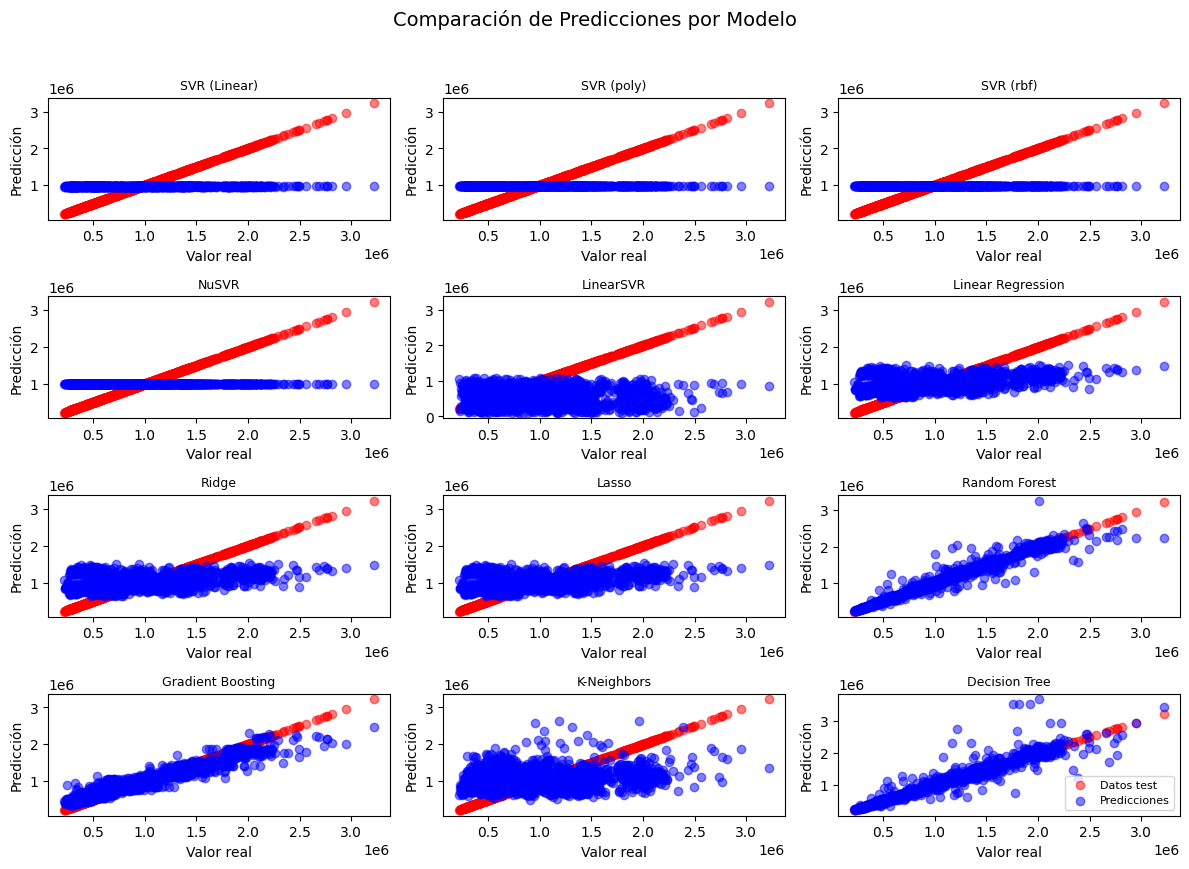

In [50]:
from sklearn.metrics import mean_squared_error, r2_score

# Listas para almacenar métricas
mse_train = []
mse_test = []
r2_train = []
r2_test = []

# Configurar figura para múltiples gráficos
plt.figure(figsize=(12, 10))

for i, (nombre, modelo) in enumerate(regresores.items()):
    modelo.fit(X_train, y_train)

    # Predicciones
    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    # Métricas
    mse_tr = mean_squared_error(y_train, y_pred_train)
    mse_te = mean_squared_error(y_test, y_pred_test)
    r2_tr = r2_score(y_train, y_pred_train)
    r2_te = r2_score(y_test, y_pred_test)

    # Guardar métricas
    mse_train.append(mse_tr)
    mse_test.append(mse_te)
    r2_train.append(r2_tr)
    r2_test.append(r2_te)

    # Imprimir resultados
    print(f"Modelo: {nombre} - MSE: {mse_te:.6f} $R^2$: {r2_te:.6f}")

    # Graficar resultados
    plt.subplot(5, 3, i+1)
    plt.scatter(y_test, y_test, color='red', alpha=0.5, label='Datos test')
    plt.scatter(y_test, y_pred_test, color='blue', alpha=0.5, label='Predicciones')
    plt.title(nombre, fontsize=9)
    plt.xlabel('Valor real')
    plt.ylabel('Predicción')
    plt.tight_layout()

plt.legend(loc='lower right', fontsize=8)
plt.suptitle("Comparación de Predicciones por Modelo", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Fuera del bucle vamos a comparar el MSE de los modelos con un gráfico de barras donde se vea train y test. Esto nos ayudará a detectar posibles underfitting y overfitting y ver desempeño de los modelos.

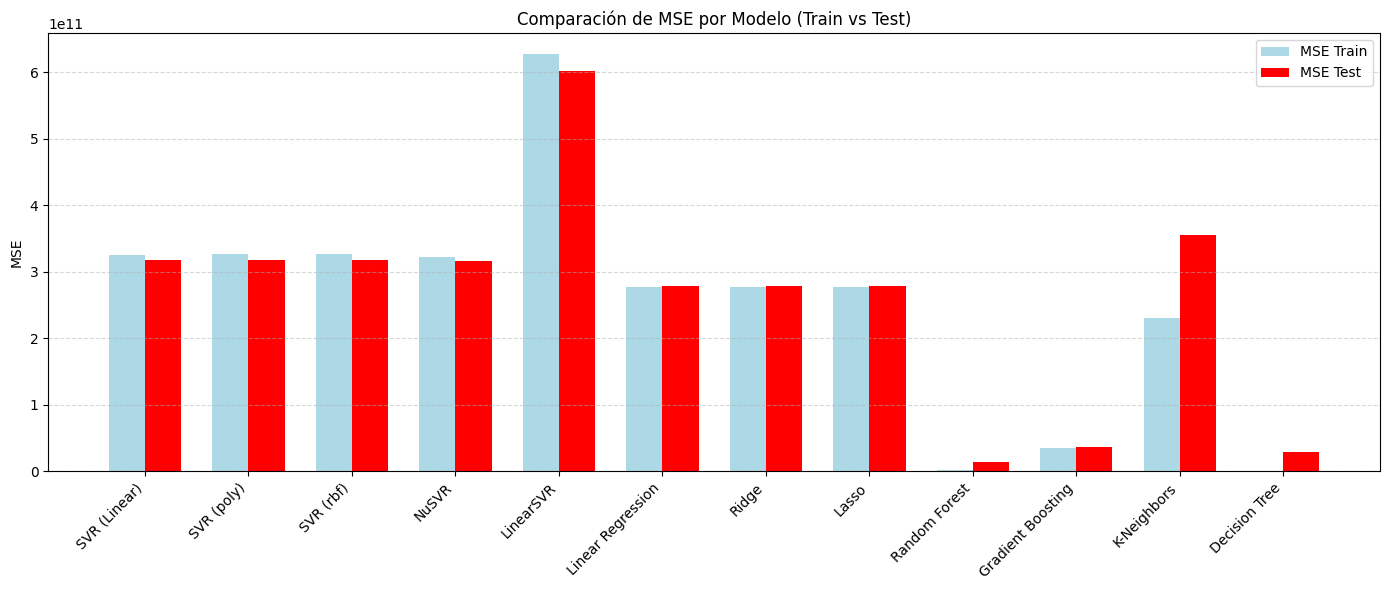

In [51]:
nombres_modelos = list(regresores.keys())
x = np.arange(len(nombres_modelos))
ancho = 0.35

# Figura
plt.figure(figsize=(14, 6))
plt.bar(x - ancho / 2, mse_train, ancho, label="MSE Train", color="lightblue")
plt.bar(x + ancho / 2, mse_test, ancho, label="MSE Test", color="red")

# Etiquetas y leyenda
plt.ylabel("MSE")
plt.title("Comparación de MSE por Modelo (Train vs Test)")
plt.xticks(ticks=x, labels=nombres_modelos, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

## ENTREGA 4: Muestra:
### a) Etapas y pasos de la actividad con el texto, el código y los gráficos y resultados que se generan en un notebook de Jupyter.
Se encuentra en las celdas de arriba.

### b) Responde mirando tu gráfico de MSE:
- El peor modelo parece ser: `LinearSVR`, debido a que tiene el mayor error en Train y Test.
- El mejor modelo parece ser: `Random Forest`, debido a que tiene el menor error en Train y Test.
- Cuál es el que tiene más overfitting: `K-Neighbours`, debido a que es el que tiene mayor diferencia de error entre Train y Test.

De manera similar haz un gráfico de barras donde aparezca el R2 de cada modelo.

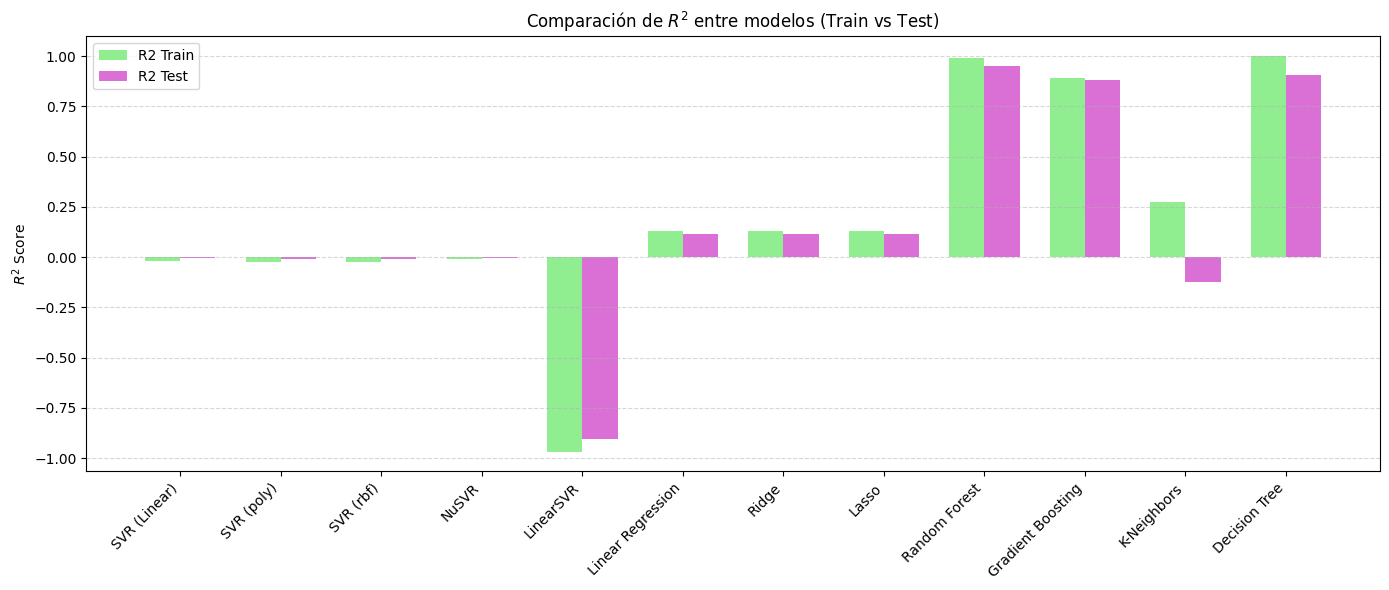

In [52]:
x = np.arange(len(nombres_modelos))
ancho = 0.35

# Figura
plt.figure(figsize=(14, 6))
plt.bar(x - ancho / 2, r2_train, ancho, label="R2 Train", color="lightgreen")
plt.bar(x + ancho / 2, r2_test, ancho, label="R2 Test", color="orchid")

# Etiquetas y leyenda
plt.ylabel("$R^2$ Score")
plt.title("Comparación de $R^2$ entre modelos (Train vs Test)")
plt.xticks(ticks=x, labels=nombres_modelos, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

## ENTREGA 5: Responde:
### a) Responde mirando tu gráfico de R2:
- El peor modelo y sus R2 de train y test: `LinearSVR`. R2 Train aproximado: -0'96 | R2 Test aproximado: -0'85
- El mejor modelo y sus R2 de train y test: `Random Forest`. R2 Train aproximado: 0'99 | R2 Test aproximado: 0'95
- Cuál es el que tiene más overfitting: `K-Neighbours`. R2 Train aproximado: 0'27 | R2 Test aproximado: -0'12

Escoge uno de los modelos de máquinas de soporte vectorial y ajusta sus hiperparámetros a mano hasta que mejores su R2 con respecto el valor inicial.

In [53]:
from sklearn.svm import SVR

# He escogido el modelo: SVR (rbf)
modelo_svr_optimo = Pipeline(
    [
        ("pre", preprocesador),
        ("regresor", SVR(kernel="rbf", C=10, epsilon=0.05, gamma=0.01)),
    ]
)

modelo_svr_optimo.fit(X_train, y_train)
y_pred_test_svr = modelo_svr_optimo.predict(X_test)

r2_svr_optimo = r2_score(y_test, y_pred_test_svr)
print(f"SVR (rbf) ajustado - R2 en test: {r2_svr_optimo:.4f}")

SVR (rbf) ajustado - R2 en test: -0.0082


Si K-NN tiene overfitting, intenta mejorar la configuración del modelo de la misma forma.

In [54]:
from sklearn.neighbors import KNeighborsRegressor

modelo_knn_optimo = Pipeline([
    ('pre', preprocesador),
    ('regresor', KNeighborsRegressor(n_neighbors=10, weights='distance'))
])

modelo_knn_optimo.fit(X_train, y_train)
y_pred_test_knn = modelo_knn_optimo.predict(X_test)

r2_knn_optimo = r2_score(y_test, y_pred_test_knn)
print(f"K-Neighbors ajustado - R2 en test: {r2_knn_optimo:.4f}")

K-Neighbors ajustado - R2 en test: -0.0530


## ENTREGA 6: Muestra:
### a) Nombre del modelo SVR que has escogido.
He elegido el modelo: SVR (rbf).

### b) MSE y R2 original del SVR:
- MSE: 318317842890.413025
- $R^2$: -0.008405

### c) Código que realice los cambios a la configuración de los modelos SVR y K-NN, los entrene y calcule sus nuevos scores.
Son las dos celdas de código que se encuentran arriba.

### d) Gráfico de puntos de datos de test y predicciones de ambos.
Se encuentra en la celda de abajo.

### e) MSE y R2 mejorado de ambos:
SVR (rbf) mejorado
- MSE: 318264977569.6498
- R2: -0.0082

K-Neighbors mejorado
- MSE: 332406867060.4417
- R2: -0.0530

SVR (rbf) mejorado
R² en test: -0.0082
MSE en test: 318264977569.6498

K-Neighbors mejorado
R² en test: -0.0530
MSE en test: 332406867060.4417


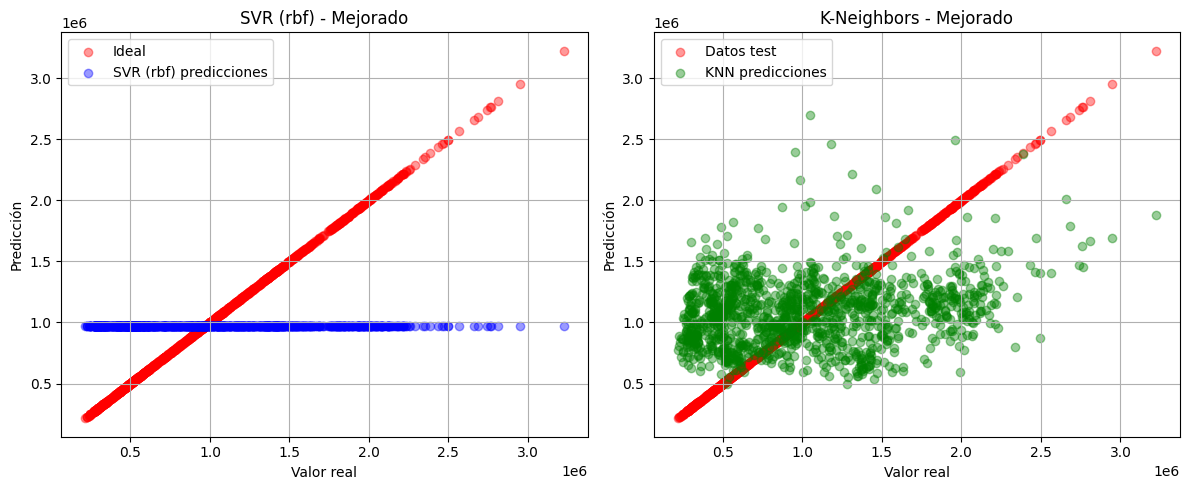

In [55]:
# SVR (rbf) mejorado
modelo_svr_opt = Pipeline([
    ('pre', preprocesador),
    ('regresor', SVR(kernel='rbf', C=10, epsilon=0.05, gamma=0.01))
])

modelo_svr_opt.fit(X_train, y_train)
y_pred_svr = modelo_svr_opt.predict(X_test)

mse_svr = mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("SVR (rbf) mejorado")
print(f"R² en test: {r2_svr:.4f}")
print(f"MSE en test: {mse_svr:.4f}")


# K-Neighbors mejorado
modelo_knn_opt = Pipeline([
    ('pre', preprocesador),
    ('regresor', KNeighborsRegressor(n_neighbors=10, weights='distance'))
])

modelo_knn_opt.fit(X_train, y_train)
y_pred_knn = modelo_knn_opt.predict(X_test)

mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("\nK-Neighbors mejorado")
print(f"R² en test: {r2_knn:.4f}")
print(f"MSE en test: {mse_knn:.4f}")


# Gráficos
plt.figure(figsize=(12, 5))

# SVR (rbf)
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_test, color='red', alpha=0.4, label='Ideal')
plt.scatter(y_test, y_pred_svr, color='blue', alpha=0.4, label='SVR (rbf) predicciones')
plt.title('SVR (rbf) - Mejorado')
plt.xlabel('Valor real')
plt.ylabel('Predicción')
plt.legend()
plt.grid(True)

# K-Neighbors
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test, color='red', alpha=0.4, label='Datos test')
plt.scatter(y_test, y_pred_knn, color='green', alpha=0.4, label='KNN predicciones')
plt.title('K-Neighbors - Mejorado')
plt.xlabel('Valor real')
plt.ylabel('Predicción')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
